# BeyondSmile: A Challenge on Detecting Depression through Facial Behavior and Head Gestures


In [1]:
import pandas as pd
import numpy as np
import tsfel
import neurokit2 as nk
import matplotlib.pyplot as plt
import datetime
import json
import pycatch22
import math
import shapely

# Read the columns for the data

In [2]:
columns_tself = pd.read_csv('./columns_aft_tsfel_ff.csv')

In [3]:
del columns_tself['Unnamed: 0']

In [4]:
tself_columns_aft = list(columns_tself.columns)


In [5]:
tself_columns_mor = [name.replace('_aft_', '_mor_') for name in tself_columns_aft]
tself_columns_mid = [name.replace('_aft_', '_mid_') for name in tself_columns_aft]
tself_columns_eve = [name.replace('_aft_', '_eve_') for name in tself_columns_aft]

In [6]:
data_phq = pd.read_csv('./dataset/groundtruth/phq9 _date.csv')


# Read the labels

In [ ]:
for record in [11, 24, 36, 32, 34, 33, 31]:
    print(record)

    data_phq = pd.read_csv('./dataset/groundtruth/phq9 _date.csv')
    data_patient_depression = data_phq.loc[record]
    patient = data_phq.loc[record]['pid']
    diagnosis = data_phq.loc[record]['depression_episode']
    start_monitoring = data_patient_depression.start_ts
    end_monitoring = data_patient_depression.end_ts
    #Change the dates into the timestamp
    element_start = datetime.datetime(2022, int(start_monitoring.split('/')[0]), int(start_monitoring.split('/')[1]))
    timestamp_start = datetime.datetime.timestamp(element_start)
    element_end = datetime.datetime(2022, int(end_monitoring.split('/')[0]), int(end_monitoring.split('/')[1]))
    timestamp_end = datetime.datetime.timestamp(element_end)
    #Reorder the data
    with open('./dataset/data/'+patient+ '.json', 'r') as f:
            data = json.load(f)

    times = []
    numbers = []
    for i in range(0, len(data)):
        times.append(int(data[i]['timestamp'])/1000)
        numbers.append(i)
    min_value = datetime.datetime.fromtimestamp(min(times)).isoformat()
    max_value = datetime.datetime.fromtimestamp(max(times)).isoformat()
    b = enumerate(times)
    c = sorted(b, key = lambda i:i[1])
    times_index_primary = []

    for e in c:
        times_index_primary.append(e[0])

    sorted_times = sorted(times)
    # Reorder data json
    data2 = []
    for i in range(0, len(times_index_primary)):
        data2.append(data[times_index_primary[i]])
    times = []
    numbers = []
    for i in range(0, len(data2)):
        times.append(int(data2[i]['timestamp'])/1000)
        numbers.append(i)
    # Find the beginning of the record and end of the record
    counter_start = 0
    while(sorted_times[counter_start]<timestamp_start):
        counter_start +=1
    counter_end = counter_start
    for i in range(counter_start, len(sorted_times)):
        if sorted_times[counter_end]<=timestamp_end:
            counter_end +=1
        else:
            break
    counter_end = counter_end - 1
    #Select subdataset
    data3 = data2[counter_start:counter_end+1]
    # Select the day for 4 periods: midnight (12am-6am), morning (6am-12pm), afternoon (12pm-6pm), and evening (6pm12am) (to daytime!)
    midnight_time = []
    morning_time = []
    afternoon_time = []
    evening_time = []
    for i in range(0, len(data3)):
        hour_sample = datetime.datetime.fromtimestamp(float(data3[i]['timestamp'])/1000).hour
        if hour_sample>=0 and hour_sample<6:
            midnight_time.append(i)
        if hour_sample>=6 and hour_sample<12:
            morning_time.append(i)
        if hour_sample>=12 and hour_sample<18:
            afternoon_time.append(i)
        if hour_sample>=18 and hour_sample<=23:
            evening_time.append(i)
    data_midnight = []
    for i in range(0, len(midnight_time)):
        data_midnight.append(data3[midnight_time[i]])  
    data_morning = []
    for i in range(0, len(morning_time)):
        data_morning.append(data3[morning_time[i]])
    data_afternoon = []
    for i in range(0, len(afternoon_time)):
        data_afternoon.append(data3[afternoon_time[i]])
    data_evening = []
    for i in range(0, len(evening_time)):
        data_evening.append(data3[evening_time[i]])




    # Midnight
    columns_mid_ff = []
    for i in range(0, 133):
        for j in range(i+1, 133):
            if i == j:
                pass
            else:
                columns_mid_ff.append(str(i) + '_' + str(j) + 'distance_mid')
                columns_mid_ff.append(str(i) + '_' + str(j) + 'angle_mid')

    facial_distances_angles_mid = pd.DataFrame(columns=columns_mid_ff+['left_eye_area_mid', 'right_eye_area_mid', 'lips_area_mid'])

    facial_metrics_row = []

    for sample in range(0, len(data_midnight)):
        try:
            contours = data_midnight[sample]['contours']
            for i in range(0, 133):
                for j in range(i+1, 133):
                    if i == j:
                        pass
                    else:
                        p0 = [contours[i]['x'], contours[i]['y']]
                        p1 = [contours[j]['x'], contours[j]['y']]
                        #Calculate distance
                        distance = math.dist(p0, p1)
                        #Calculate angle
                        if contours[i]['x']!= contours[j]['x']:
                            a= (contours[j]['y'] - contours[i]['y'])/(contours[j]['x'] - contours[i]['x'])
                        else:
                            a = 99999999999
                        angle = math.atan(a)
                        facial_metrics_row.append(distance)
                        facial_metrics_row.append(angle)
            #Add the new row


                    #Compute area of left eye
            list_left_eye = []
            for points in range(56, 72):
                list_left_eye.append((contours[points]['x'], contours[points]['y']))
            list_left_eye.append((contours[56]['x'], contours[56]['y']))
            polygon = shapely.Polygon(list_left_eye)
            left_eye_area = polygon.area 
            facial_metrics_row.append(left_eye_area)

            #Compute area of rigt eye
            list_right_eye = []
            for points in range(72, 88):
                list_right_eye.append((contours[points]['x'], contours[points]['y']))
            list_right_eye.append((contours[72]['x'], contours[72]['y']))
            polygon = shapely.Polygon(list_right_eye)
            right_eye_area = polygon.area 
            facial_metrics_row.append(right_eye_area)


             #Compute area of lips
            list_lips = []
            for points in range(88, 126):
                list_lips.append((contours[points]['x'], contours[points]['y']))
            list_lips.append((contours[88]['x'], contours[88]['y']))
            polygon = shapely.Polygon(list_lips)
            list_lips = polygon.area 
            facial_metrics_row.append(list_lips)


            facial_distances_angles_mid.loc[len(facial_distances_angles_mid)] = facial_metrics_row
            facial_metrics_row = []
        except:
            facial_distances_angles_mid.loc[len(facial_distances_angles_mid)] = [np.nan]*17559
            facial_metrics_row = []

    try:
        facial_distances_angles_mid['ratio_eyes_mid'] = facial_distances_angles_mid['56_64distance_mid'] + facial_distances_angles_mid['60_68distance_mid']+ facial_distances_angles_mid['72_80distance_mid']+facial_distances_angles_mid['76_84distance_mid']
    except:
        facial_distances_angles_mid['ratio_eyes_mid'] = np.nan

    facial_distances_angles_mid_cleaned = facial_distances_angles_mid.copy()
    facial_distances_angles_mid_cleaned = facial_distances_angles_mid_cleaned.dropna()

    if (len(facial_distances_angles_mid_cleaned)>12):
        #Normalise the distances
        columns_to_check = list(facial_distances_angles_mid.columns[0:-3])
        columns_to_normalise = []
        for name_column in columns_to_check:
            if 'distance' in name_column:
                if name_column!='64_72distance_mid':
                    columns_to_normalise.append(name_column)
        facial_distances_angles_mid_cleaned[columns_to_normalise]= facial_distances_angles_mid_cleaned[columns_to_normalise].div(facial_distances_angles_mid_cleaned['64_72distance_mid'], axis=0)
        facial_distances_angles_mid_cleaned[facial_distances_angles_mid_cleaned.columns[-3:]] = facial_distances_angles_mid_cleaned[facial_distances_angles_mid_cleaned.columns[-3:]].div(facial_distances_angles_mid_cleaned['64_72distance_mid']**2, axis=0)

    if len(facial_distances_angles_mid_cleaned) >=12:     # Retrieves a pre-defined feature configuration file to extract the temporal, statistical and spectral feature sets
        cfg = tsfel.get_features_by_domain()

        # Extract features
        X = tsfel.time_series_features_extractor(cfg, facial_distances_angles_mid_cleaned)
        X_mid_to_delete = []
        for name in X.columns:
            if 'Spectrogram mean coefficient_' in name:
                X_mid_to_delete.append(name)
        X = X.drop(X_mid_to_delete, axis=1)

    else:
        X = pd.DataFrame(columns=tself_columns_mid)
        X.loc[0] = [np.nan]*2177440

    data_ff_mid = X.copy()

    approx_entropy_columns = [name + '_app_ent' for name in facial_distances_angles_mid_cleaned.columns]
    data_approx_entropy_mid = pd.DataFrame(columns=approx_entropy_columns)
    app_ent_ff_mid= []

    for i in range(0, len(approx_entropy_columns)): 
        try:
            approximate_entropy, parameters = nk.entropy_approximate(facial_distances_angles_mid_cleaned[facial_distances_angles_mid_cleaned.columns[i]])
             # Approximate entropy
        except:
            approximate_entropy = 0
        app_ent_ff_mid.append(approximate_entropy)
    data_approx_entropy_mid.loc[0] = app_ent_ff_mid

    data_approx_entropy_mid

    data_ff_mid = pd.concat([data_ff_mid, data_approx_entropy_mid], axis=1)

    rsd_columns_mid = [name + '_rsd' for name in facial_distances_angles_mid_cleaned.columns]
    data_rsd_mid = pd.DataFrame(columns=rsd_columns_mid)
    rsd_ff_mid = []
    for i in range(0, len(rsd_columns_mid)): 
        rsd = 100*np.std(facial_distances_angles_mid_cleaned[facial_distances_angles_mid_cleaned.columns[i]])/(np.mean(facial_distances_angles_mid_cleaned[facial_distances_angles_mid_cleaned.columns[i]])+0.00000000000000000000001)
        rsd_ff_mid.append(rsd)
    data_rsd_mid.loc[0] = rsd_ff_mid
    data_ff_mid = pd.concat([data_ff_mid, data_rsd_mid], axis=1)
    # For morning
    columns_mor_ff = []
    for i in range(0, 133):
        for j in range(i+1, 133):
            if i == j:
                pass
            else:
                columns_mor_ff.append(str(i) + '_' + str(j) + 'distance_mor')
                columns_mor_ff.append(str(i) + '_' + str(j) + 'angle_mor')
    facial_distances_angles_mor = pd.DataFrame(columns=columns_mor_ff+['left_eye_area_mor', 'right_eye_area_mor', 'lips_area_mor'])
    facial_metrics_row = []
    for sample in range(0, len(data_morning)):
        try:
            contours = data_morning[sample]['contours']
            for i in range(0, 133):
                for j in range(i+1, 133):
                    if i == j:
                        pass
                    else:
                        p0 = [contours[i]['x'], contours[i]['y']]
                        p1 = [contours[j]['x'], contours[j]['y']]
                        #Calculate distance
                        distance = math.dist(p0, p1)
                        #Calculate angle
                        if contours[i]['x']!= contours[j]['x']:
                            a= (contours[j]['y'] - contours[i]['y'])/(contours[j]['x'] - contours[i]['x'])
                        else:
                            a = 99999999999
                        angle = math.atan(a)
                        facial_metrics_row.append(distance)
                        facial_metrics_row.append(angle)
            #Add the new row


                    #Compute area of left eye
            list_left_eye = []
            for points in range(56, 72):
                list_left_eye.append((contours[points]['x'], contours[points]['y']))
            list_left_eye.append((contours[56]['x'], contours[56]['y']))
            polygon = shapely.Polygon(list_left_eye)
            left_eye_area = polygon.area 
            facial_metrics_row.append(left_eye_area)

            #Compute area of rigt eye
            list_right_eye = []
            for points in range(72, 88):
                list_right_eye.append((contours[points]['x'], contours[points]['y']))
            list_right_eye.append((contours[72]['x'], contours[72]['y']))
            polygon = shapely.Polygon(list_right_eye)
            right_eye_area = polygon.area 
            facial_metrics_row.append(right_eye_area)

             #Compute area of lips
            list_lips = []
            for points in range(88, 126):
                list_lips.append((contours[points]['x'], contours[points]['y']))
            list_lips.append((contours[88]['x'], contours[88]['y']))
            polygon = shapely.Polygon(list_lips)
            list_lips = polygon.area 
            facial_metrics_row.append(list_lips)


            facial_distances_angles_mor.loc[len(facial_distances_angles_mor)] = facial_metrics_row
            facial_metrics_row = []
        except:
            facial_distances_angles_mor.loc[len(facial_distances_angles_mor)] = [np.nan]*17559
            facial_metrics_row = []

    try:
        facial_distances_angles_mor['ratio_eyes_mor'] = facial_distances_angles_mor['56_64distance_mor'] + facial_distances_angles_mor['60_68distance_mor']+ facial_distances_angles_mor['72_80distance_mor']+facial_distances_angles_mor['76_84distance_mor']
    except:
        facial_distances_angles_mor['ratio_eyes_mor'] = np.nan

    facial_distances_angles_mor_cleaned = facial_distances_angles_mor.copy()
    facial_distances_angles_mor_cleaned = facial_distances_angles_mor_cleaned.dropna()

    if (len(facial_distances_angles_mor_cleaned)>12):
        #Normalise the distances
        columns_to_check = list(facial_distances_angles_mor.columns[0:-3])
        columns_to_normalise = []
        for name_column in columns_to_check:
            if 'distance' in name_column:
                if name_column!='64_72distance_mor':
                    columns_to_normalise.append(name_column)
        facial_distances_angles_mor_cleaned[columns_to_normalise]= facial_distances_angles_mor_cleaned[columns_to_normalise].div(facial_distances_angles_mor_cleaned['64_72distance_mor'], axis=0)
        facial_distances_angles_mor_cleaned[facial_distances_angles_mor_cleaned.columns[-3:]] = facial_distances_angles_mor_cleaned[facial_distances_angles_mor_cleaned.columns[-3:]].div(facial_distances_angles_mor_cleaned['64_72distance_mor']**2, axis=0)

    if len(facial_distances_angles_mor_cleaned) >=12:     # Retrieves a pre-defined feature configuration file to extract the temporal, statistical and spectral feature sets
        cfg = tsfel.get_features_by_domain()

        # Extract features
        X = tsfel.time_series_features_extractor(cfg, facial_distances_angles_mor_cleaned)
        X_mor_to_delete = []
        for name in X.columns:
            if 'Spectrogram mean coefficient_' in name:
                X_mor_to_delete.append(name)
        X = X.drop(X_mor_to_delete, axis=1)

    else:
        X = pd.DataFrame(columns=tself_columns_mor)
        X.loc[0] = [np.nan]*2177440

    data_ff_mor = X.copy()

    approx_entropy_columns = [name + '_app_ent' for name in facial_distances_angles_mor_cleaned.columns]
    data_approx_entropy_mor = pd.DataFrame(columns=approx_entropy_columns)
    app_ent_ff_mor= []

    for i in range(0, len(approx_entropy_columns)): 
        try:
            approximate_entropy, parameters = nk.entropy_approximate(facial_distances_angles_mor_cleaned[facial_distances_angles_mor_cleaned.columns[i]])
             # Approximate entropy
        except:
            approximate_entropy = 0
        app_ent_ff_mor.append(approximate_entropy)
    data_approx_entropy_mor.loc[0] = app_ent_ff_mor

    data_ff_mor = pd.concat([data_ff_mor, data_approx_entropy_mor], axis=1)

    rsd_columns_mor = [name + '_rsd' for name in facial_distances_angles_mor_cleaned.columns]
    data_rsd_mor = pd.DataFrame(columns=rsd_columns_mor)
    rsd_ff_mor = []
    for i in range(0, len(rsd_columns_mor)): 
        rsd = 100*np.std(facial_distances_angles_mor_cleaned[facial_distances_angles_mor_cleaned.columns[i]])/(np.mean(facial_distances_angles_mor_cleaned[facial_distances_angles_mor_cleaned.columns[i]])+0.00000000000000000000001)
        rsd_ff_mor.append(rsd)
    data_rsd_mor.loc[0] = rsd_ff_mor
    data_ff_mor = pd.concat([data_ff_mor, data_rsd_mor], axis=1)

    # Afternoon
    columns_aft_ff = []
    for i in range(0, 133):
        for j in range(i+1, 133):
            if i == j:
                pass
            else:
                columns_aft_ff.append(str(i) + '_' + str(j) + 'distance_aft')
                columns_aft_ff.append(str(i) + '_' + str(j) + 'angle_aft')

    facial_distances_angles_aft = pd.DataFrame(columns=columns_aft_ff+['left_eye_area_aft', 'right_eye_area_aft', 'lips_area_aft'])
    facial_metrics_row = []
    for sample in range(0, len(data_afternoon)):
        try:
            contours = data_afternoon[sample]['contours']
            for i in range(0, 133):
                for j in range(i+1, 133):
                    if i == j:
                        pass
                    else:
                        p0 = [contours[i]['x'], contours[i]['y']]
                        p1 = [contours[j]['x'], contours[j]['y']]
                        #Calculate distance
                        distance = math.dist(p0, p1)
                        #Calculate angle
                        if contours[i]['x']!= contours[j]['x']:
                            a= (contours[j]['y'] - contours[i]['y'])/(contours[j]['x'] - contours[i]['x'])
                        else:
                            a = 99999999999
                        angle = math.atan(a)
                        facial_metrics_row.append(distance)
                        facial_metrics_row.append(angle)
            #Add the new row


                    #Compute area of left eye
            list_left_eye = []
            for points in range(56, 72):
                list_left_eye.append((contours[points]['x'], contours[points]['y']))
            list_left_eye.append((contours[56]['x'], contours[56]['y']))
            polygon = shapely.Polygon(list_left_eye)
            left_eye_area = polygon.area 
            facial_metrics_row.append(left_eye_area)

            #Compute area of rigt eye
            list_right_eye = []
            for points in range(72, 88):
                list_right_eye.append((contours[points]['x'], contours[points]['y']))
            list_right_eye.append((contours[72]['x'], contours[72]['y']))
            polygon = shapely.Polygon(list_right_eye)
            right_eye_area = polygon.area 
            facial_metrics_row.append(right_eye_area)


             #Compute area of lips
            list_lips = []
            for points in range(88, 126):
                list_lips.append((contours[points]['x'], contours[points]['y']))
            list_lips.append((contours[88]['x'], contours[88]['y']))
            polygon = shapely.Polygon(list_lips)
            list_lips = polygon.area 
            facial_metrics_row.append(list_lips)


            facial_distances_angles_aft.loc[len(facial_distances_angles_aft)] = facial_metrics_row
            facial_metrics_row = []
        except:
            facial_distances_angles_aft.loc[len(facial_distances_angles_aft)] = [np.nan]*17559
            facial_metrics_row = []

    try:
        facial_distances_angles_aft['ratio_eyes_aft'] = facial_distances_angles_aft['56_64distance_aft'] + facial_distances_angles_aft['60_68distance_aft']+ facial_distances_angles_aft['72_80distance_aft']+facial_distances_angles_aft['76_84distance_aft']
    except:
        facial_distances_angles_aft['ratio_eyes_aft'] = np.nan

    facial_distances_angles_aft_cleaned = facial_distances_angles_aft.copy()
    facial_distances_angles_aft_cleaned = facial_distances_angles_aft_cleaned.dropna()
    if (len(facial_distances_angles_aft_cleaned)>12):
        #Normalise the distances
        columns_to_check = list(facial_distances_angles_aft.columns[0:-3])
        columns_to_normalise = []
        for name_column in columns_to_check:
            if 'distance' in name_column:
                if name_column!='64_72distance_aft':
                    columns_to_normalise.append(name_column)
        facial_distances_angles_aft_cleaned[columns_to_normalise]= facial_distances_angles_aft_cleaned[columns_to_normalise].div(facial_distances_angles_aft_cleaned['64_72distance_aft'], axis=0)
        facial_distances_angles_aft_cleaned[facial_distances_angles_aft_cleaned.columns[-3:]] = facial_distances_angles_aft_cleaned[facial_distances_angles_aft_cleaned.columns[-3:]].div(facial_distances_angles_aft_cleaned['64_72distance_aft']**2, axis=0)

    if len(facial_distances_angles_aft_cleaned) >=12:     # Retrieves a pre-defined feature configuration file to extract the temporal, statistical and spectral feature sets
        cfg = tsfel.get_features_by_domain()

        # Extract features
        X = tsfel.time_series_features_extractor(cfg, facial_distances_angles_aft_cleaned)
        X_aft_to_delete = []
        for name in X.columns:
            if 'Spectrogram mean coefficient_' in name:
                X_aft_to_delete.append(name)
        X = X.drop(X_aft_to_delete, axis=1)

    else:
        X = pd.DataFrame(columns=tself_columns_aft)
        X.loc[0] = [np.nan]*2177440

    data_ff_aft = X.copy()

    approx_entropy_columns = [name + '_app_ent' for name in facial_distances_angles_aft_cleaned.columns]
    data_approx_entropy_aft = pd.DataFrame(columns=approx_entropy_columns)
    app_ent_ff_aft= []

    for i in range(0, len(approx_entropy_columns)): 
        try:
            approximate_entropy, parameters = nk.entropy_approximate(facial_distances_angles_aft_cleaned[facial_distances_angles_aft_cleaned.columns[i]])
             # Approximate entropy
        except:
            approximate_entropy = 0
        app_ent_ff_aft.append(approximate_entropy)
    data_approx_entropy_aft.loc[0] = app_ent_ff_aft
    data_ff_aft = pd.concat([data_ff_aft, data_approx_entropy_aft], axis=1)

    rsd_columns_aft = [name + '_rsd' for name in facial_distances_angles_aft_cleaned.columns]
    data_rsd_aft = pd.DataFrame(columns=rsd_columns_aft)
    rsd_ff_aft = []
    for i in range(0, len(rsd_columns_aft)): 
        rsd = 100*np.std(facial_distances_angles_aft_cleaned[facial_distances_angles_aft_cleaned.columns[i]])/(np.mean(facial_distances_angles_aft_cleaned[facial_distances_angles_aft_cleaned.columns[i]])+0.00000000000000000000001)
        rsd_ff_aft.append(rsd)
    data_rsd_aft.loc[0] = rsd_ff_aft
    data_ff_aft = pd.concat([data_ff_aft, data_rsd_aft], axis=1)
    # Evening
    columns_eve_ff = []
    for i in range(0, 133):
        for j in range(i+1, 133):
            if i == j:
                pass
            else:
                columns_eve_ff.append(str(i) + '_' + str(j) + 'distance_eve')
                columns_eve_ff.append(str(i) + '_' + str(j) + 'angle_eve')

    facial_distances_angles_eve = pd.DataFrame(columns=columns_eve_ff+['left_eye_area_eve', 'right_eye_area_eve', 'lips_area_eve'])
    facial_metrics_row = []
    for sample in range(0, len(data_evening)):
        try:
            contours = data_evening[sample]['contours']
            for i in range(0, 133):
                for j in range(i+1, 133):
                    if i == j:
                        pass
                    else:
                        p0 = [contours[i]['x'], contours[i]['y']]
                        p1 = [contours[j]['x'], contours[j]['y']]
                        #Calculate distance
                        distance = math.dist(p0, p1)
                        #Calculate angle
                        if contours[i]['x']!= contours[j]['x']:
                            a= (contours[j]['y'] - contours[i]['y'])/(contours[j]['x'] - contours[i]['x'])
                        else:
                            a = 99999999999
                        angle = math.atan(a)
                        facial_metrics_row.append(distance)
                        facial_metrics_row.append(angle)
            #Add the new row


                    #Compute area of left eye
            list_left_eye = []
            for points in range(56, 72):
                list_left_eye.append((contours[points]['x'], contours[points]['y']))
            list_left_eye.append((contours[56]['x'], contours[56]['y']))
            polygon = shapely.Polygon(list_left_eye)
            left_eye_area = polygon.area 
            facial_metrics_row.append(left_eye_area)

            #Compute area of rigt eye
            list_right_eye = []
            for points in range(72, 88):
                list_right_eye.append((contours[points]['x'], contours[points]['y']))
            list_right_eye.append((contours[72]['x'], contours[72]['y']))
            polygon = shapely.Polygon(list_right_eye)
            right_eye_area = polygon.area 
            facial_metrics_row.append(right_eye_area)



             #Compute area of lips
            list_lips = []
            for points in range(88, 126):
                list_lips.append((contours[points]['x'], contours[points]['y']))
            list_lips.append((contours[88]['x'], contours[88]['y']))
            polygon = shapely.Polygon(list_lips)
            list_lips = polygon.area 
            facial_metrics_row.append(list_lips)


            facial_distances_angles_eve.loc[len(facial_distances_angles_eve)] = facial_metrics_row
            facial_metrics_row = []
        except:
            facial_distances_angles_eve.loc[len(facial_distances_angles_eve)] = [np.nan]*17559
            facial_metrics_row = []

    try:
        facial_distances_angles_eve['ratio_eyes_eve'] = facial_distances_angles_eve['56_64distance_eve'] + facial_distances_angles_eve['60_68distance_eve']+ facial_distances_angles_eve['72_80distance_eve']+facial_distances_angles_eve['76_84distance_eve']
    except:
        facial_distances_angles_eve['ratio_eyes_eve'] = np.nan

    facial_distances_angles_eve_cleaned = facial_distances_angles_eve.copy()
    facial_distances_angles_eve_cleaned = facial_distances_angles_eve_cleaned.dropna()

    if (len(facial_distances_angles_eve_cleaned)>12):
        #Normalise the distances
        columns_to_check = list(facial_distances_angles_eve.columns[0:-3])
        columns_to_normalise = []
        for name_column in columns_to_check:
            if 'distance' in name_column:
                if name_column!='64_72distance_eve':
                    columns_to_normalise.append(name_column)
        facial_distances_angles_eve_cleaned[columns_to_normalise]= facial_distances_angles_eve_cleaned[columns_to_normalise].div(facial_distances_angles_eve_cleaned['64_72distance_eve'], axis=0)
        facial_distances_angles_eve_cleaned[facial_distances_angles_eve_cleaned.columns[-3:]] = facial_distances_angles_eve_cleaned[facial_distances_angles_eve_cleaned.columns[-3:]].div(facial_distances_angles_eve_cleaned['64_72distance_eve']**2, axis=0)
        facial_distances_angles_eve_cleaned['ratio_eyes_eve'] = facial_distances_angles_eve_cleaned['56_64distance_eve'] + facial_distances_angles_eve_cleaned['60_68distance_eve']+ facial_distances_angles_eve_cleaned['72_80distance_eve']+facial_distances_angles_eve_cleaned['76_84distance_eve']

    if len(facial_distances_angles_eve_cleaned) >=12:     # Retrieves a pre-defined feature configuration file to extract the temporal, statistical and spectral feature sets
        cfg = tsfel.get_features_by_domain()

        # Extract features
        X = tsfel.time_series_features_extractor(cfg, facial_distances_angles_eve_cleaned)
        X_eve_to_delete = []
        for name in X.columns:
            if 'Spectrogram mean coefficient_' in name:
                X_eve_to_delete.append(name)
        X = X.drop(X_eve_to_delete, axis=1)

    else:
        X = pd.DataFrame(columns=tself_columns_eve)
        X.loc[0] = [np.nan]*2177440

    data_ff_eve = X.copy()

    approx_entropy_columns = [name + '_app_ent' for name in facial_distances_angles_eve_cleaned.columns]
    data_approx_entropy_eve = pd.DataFrame(columns=approx_entropy_columns)
    app_ent_ff_eve= []

    for i in range(0, len(approx_entropy_columns)): 
        try:
            approximate_entropy, parameters = nk.entropy_approximate(facial_distances_angles_eve_cleaned[facial_distances_angles_eve_cleaned.columns[i]])
             # Approximate entropy
        except:
            approximate_entropy = 0
        app_ent_ff_eve.append(approximate_entropy)
    data_approx_entropy_eve.loc[0] = app_ent_ff_eve

    data_ff_eve = pd.concat([data_ff_eve, data_approx_entropy_eve], axis=1)

    rsd_columns_eve = [name + '_rsd' for name in facial_distances_angles_eve_cleaned.columns]
    data_rsd_eve = pd.DataFrame(columns=rsd_columns_eve)
    rsd_ff_eve = []
    for i in range(0, len(rsd_columns_eve)): 
        rsd = 100*np.std(facial_distances_angles_eve_cleaned[facial_distances_angles_eve_cleaned.columns[i]])/(np.mean(facial_distances_angles_eve_cleaned[facial_distances_angles_eve_cleaned.columns[i]])+0.00000000000000000000001)
        rsd_ff_eve.append(rsd)
    data_rsd_eve.loc[0] = rsd_ff_eve
    data_ff_eve = pd.concat([data_ff_eve, data_rsd_eve], axis=1)

    # Concat all probabilites
    data_ff = pd.concat([data_ff_mid, data_ff_mor, data_ff_aft, data_ff_eve], axis=1)
    # Prepare the name of the columns for the exceptions
    information_record = pd.DataFrame(columns = ['patient', 'record', 'diagnosis', 'timestamp_start', 'timestamp_end'])
    information_record.loc[0] = [patient, record, diagnosis, timestamp_start, timestamp_end]
    data_ff = pd.concat([information_record, data_ff], axis=1, join='inner')

    data_ff.to_csv('ff_'+str(record)+'b.csv')

 #   if record == 12:
 #       data_all_ff = data_ff.copy()
 #   else:
  #      data_all_ff = pd.concat([data_all_ff, data_ff], axis= 0 )


11


C:\Users\skiju\AppData\Local\Temp\ipykernel_20664\201470258.py:182: UserWarning: Using default sampling frequency set in configuration file.
  X = tsfel.time_series_features_extractor(cfg, facial_distances_angles_mid_cleaned)


C:\Users\skiju\AppData\Local\Temp\ipykernel_20664\201470258.py:440: UserWarning: Using default sampling frequency set in configuration file.
  X = tsfel.time_series_features_extractor(cfg, facial_distances_angles_aft_cleaned)


C:\Users\skiju\AppData\Local\Temp\ipykernel_20664\201470258.py:570: UserWarning: Using default sampling frequency set in configuration file.
  X = tsfel.time_series_features_extractor(cfg, facial_distances_angles_eve_cleaned)


24


...

32


C:\Users\skiju\AppData\Local\Temp\ipykernel_20664\201470258.py:182: UserWarning: Using default sampling frequency set in configuration file.
  X = tsfel.time_series_features_extractor(cfg, facial_distances_angles_mid_cleaned)


C:\Users\skiju\AppData\Local\Temp\ipykernel_20664\201470258.py:311: UserWarning: Using default sampling frequency set in configuration file.
  X = tsfel.time_series_features_extractor(cfg, facial_distances_angles_mor_cleaned)


C:\Users\skiju\AppData\Local\Temp\ipykernel_20664\201470258.py:440: UserWarning: Using default sampling frequency set in configuration file.
  X = tsfel.time_series_features_extractor(cfg, facial_distances_angles_aft_cleaned)


C:\Users\skiju\AppData\Local\Temp\ipykernel_20664\201470258.py:570: UserWarning: Using default sampling frequency set in configuration file.
  X = tsfel.time_series_features_extractor(cfg, facial_distances_angles_eve_cleaned)


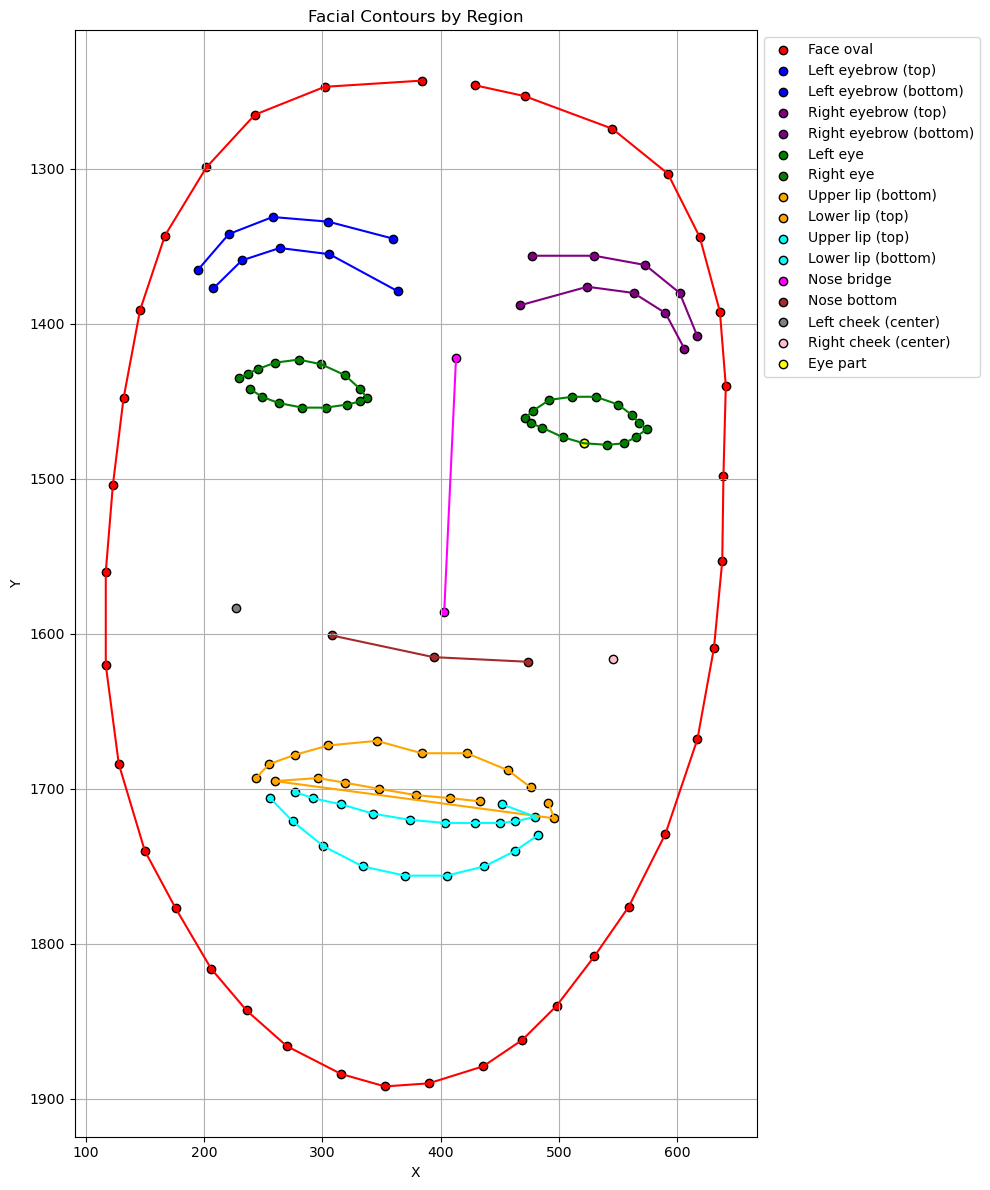

In [30]:
import matplotlib.pyplot as plt

# Contours data (list of points with x and y)
contours = data_midnight[117]['contours']

x_contour = [point['x'] for point in contours]
y_contour = [point['y'] for point in contours]

# Face parts definition: (start_index, end_index, label, color)
# If a single index or a small set, we'll treat them individually.
face_parts = [
    ((0, 35),    'Face oval',           'red'),
    ((36, 40),   'Left eyebrow (top)',  'blue'),
    ((41, 45),   'Left eyebrow (bottom)','blue'),
    ((46, 50),   'Right eyebrow (top)', 'purple'),
    ((51, 55),   'Right eyebrow (bottom)','purple'),
    ((56, 71),   'Left eye',            'green'),
    ((72, 87),   'Right eye',           'green'),
    ((88, 96),   'Upper lip (bottom)',  'orange'),
    ((97, 105),  'Lower lip (top)',     'orange'),
    ((106, 116), 'Upper lip (top)',     'cyan'),
    ((117, 125), 'Lower lip (bottom)',  'cyan')
]

# Single / small sets of points
# Nose bridge: indices 126,127
face_parts.append(((126, 127), 'Nose bridge', 'magenta'))

# Nose bottom: indices 128-130
face_parts.append(((128, 130), 'Nose bottom', 'brown'))

# Left cheek (center): index 131 only
face_parts.append(((131, 131), 'Left cheek (center)', 'gray'))

# Right cheek (center): index 132 only
face_parts.append(((132, 132), 'Right cheek (center)', 'pink'))

face_parts.append(((84, 84), 'Eye part', 'yellow'))



plt.figure(figsize=(10, 12))

# Plot each part
for (start, end), label, color in face_parts:
    # If start == end, it's a single point
    x_part = x_contour[start:end+1]
    y_part = y_contour[start:end+1]

    # Plot the points for this part
    plt.scatter(x_part, y_part, c=color, label=label, edgecolor='black')

    # Optionally, connect them with a line if it's a range > 1 point
    if end > start:
        # Connect the points in order
        plt.plot(x_part, y_part, c=color)

# Invert y-axis to match typical image coordinates
plt.gca().invert_yaxis()

plt.title('Facial Contours by Region')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()
